---

# <center> **Costco Sales Analysis Estimation Using Machine Learning**
#### <center>

---

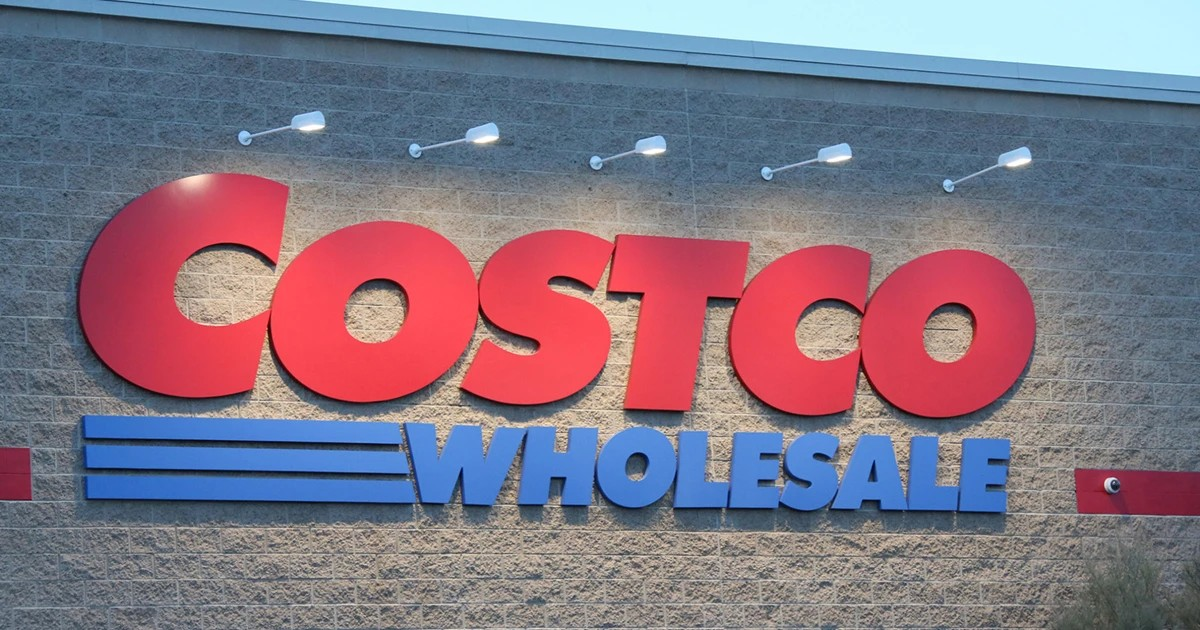

In [57]:
from IPython import display
display.Image('https://raw.githubusercontent.com/VishalAnton20/Costco-Sales-Analysis/main/img.jpg')

### **Description:**

Costco, one of the largest retail chains in the US, is aiming to enhance its sales forecasting strategy to optimize inventory and promotional planning. Sales trends are often influenced by regional events, seasonal demand, and macroeconomic indicators such as the Consumer Price Index (CPI) and Unemployment Rate.

Costco organizes a variety of promotional campaigns and discount events throughout the year. These promotional efforts often align with major holidays such as Black Friday, Labor Day, Independence Day, and Christmas, significantly impacting sales patterns. However, inconsistent prediction of these demand surges has sometimes led to stockouts or overstocking issues.

This project is designed to build an intelligent machine learning model that not only predicts weekly sales but also adjusts for the complex effects of holidays, markdown events, and regional economic factors—thereby helping Costco better plan inventory, staff, and promotional activities.

Dataset details:\
This is the historical data that covers sales from 2010-02-05 to 2012-11-01, in the file Costco_Store_sales. Within this file you will find the following fields:\
* Store - the store number
* Date - the week of sales
* Weekly_Sales -  sales for the given store
* Holiday_Flag - whether the week is a special holiday week 1 – Holiday week 0 – Non-holiday week
* Temperature - Temperature on the day of sale
* Fuel_Price - Cost of fuel in the region
* CPI – Prevailing consumer price index
* Unemployment - Prevailing unemployment rate
* Holiday Events\
Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13\
Labour Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13\
Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13\
Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

### Objective:
- Understand the Dataset & cleanup (if required).
- Build Regression models to predict the sales w.r.t a single & multiple feature.
- Also evaluate the models & compare their respective scores like R2, RMSE, etc.

---

# <center> **Stractegic Plan of Action**:

**We aim to solve the problem statement by creating a plan of action, Here are some of the necessary steps:**
1. Data Exploration
2. Exploratory Data Analysis (EDA)
3. Data Pre-processing
4. Data Manipulation
5. Feature Selection/Extraction
6. Predictive Modelling
7. Project Outcomes & Conclusion

---

# <center>1. **Data Exploration**

In [4]:
#Importing the basic librarires

import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

#from brokenaxes import brokenaxes
from statsmodels.formula import api
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10,6]

import warnings
warnings.filterwarnings('ignore')

In [6]:
#Importing the dataset

df = pd.read_csv('/content/input/Costco-dataset/Costco.csv')

#df.drop(['car name'], axis=1, inplace=True)
display(df.head())

original_df = df.copy(deep=True)

print('\n\033[1mInference:\033[0m The Datset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106



Inference: The Datset consists of 8 features & 6435 samples.


In [9]:
# Reframing the columns

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

df['weekday'] = df.Date.dt.weekday
df['month'] = df.Date.dt.month
df['year'] = df.Date.dt.year

# df['Monthly_Quarter'] = df.month.map({1:'Q1',2:'Q1',3:'Q1',4:'Q2',5:'Q2',6:'Q2',7:'Q3',
#                                       8:'Q3',9:'Q3',10:'Q4',11:'Q4',12:'Q4'})

df.drop(['Date'], axis=1, inplace=True)#,'month'

target = 'Weekly_Sales'
features = [i for i in df.columns if i not in [target]]
original_df = df.copy(deep=True)

df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,weekday,month,year
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,6,5,2010
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,3,12,2010
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,0,5,2010
5,1,1439541.59,0,57.79,2.667,211.380643,8.106,4,12,2010
8,1,1594968.28,0,62.27,2.719,210.820450,7.808,3,2,2010


In [10]:
#Checking the dtypes of all the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2565 entries, 0 to 6432
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         2565 non-null   int64  
 1   Weekly_Sales  2565 non-null   float64
 2   Holiday_Flag  2565 non-null   int64  
 3   Temperature   2565 non-null   float64
 4   Fuel_Price    2565 non-null   float64
 5   CPI           2565 non-null   float64
 6   Unemployment  2565 non-null   float64
 7   weekday       2565 non-null   int32  
 8   month         2565 non-null   int32  
 9   year          2565 non-null   int32  
dtypes: float64(5), int32(3), int64(2)
memory usage: 190.4 KB


In [11]:
#Checking number of unique rows in each feature

df.nunique().sort_values()

,0
Holiday_Flag,2
year,3
weekday,7
month,12
Store,45
Unemployment,349
Fuel_Price,453
CPI,855
Temperature,1725
Weekly_Sales,2565


In [12]:
#Checking number of unique rows in each feature

nu = df[features].nunique().sort_values()
nf = []; cf = []; nnf = 0; ncf = 0; #numerical & categorical features

for i in range(df[features].shape[1]):
    if nu.values[i]<=45:cf.append(nu.index[i])
    else: nf.append(nu.index[i])

print('\n\033[1mInference:\033[0m The Datset has {} numerical & {} categorical features.'.format(len(nf),len(cf)))


Inference: The Datset has 4 numerical & 5 categorical features.


In [13]:
#Checking the stats of all the columns

display(df.describe())

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,weekday,month,year
count,2565.000000,2.565000e+03,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000
mean,23.000000,1.059872e+06,0.105263,59.585864,3.329579,171.386349,8.022267,2.929825,6.561404,2010.929825
std,12.989706,5.573831e+05,0.306952,19.069276,0.461985,39.293112,1.878158,2.101868,3.459797,0.791769
min,1.000000,2.099862e+05,0.000000,-2.060000,2.513000,126.085452,3.879000,0.000000,1.000000,2010.000000
25%,12.000000,5.700695e+05,0.000000,45.260000,2.868000,131.586613,6.908000,1.000000,4.000000,2010.000000
50%,23.000000,9.813452e+05,0.000000,61.100000,3.417000,182.598306,7.907000,3.000000,6.000000,2011.000000
75%,34.000000,1.450733e+06,0.000000,74.570000,3.702000,212.512605,8.622000,5.000000,10.000000,2012.000000
max,45.000000,2.752122e+06,1.000000,100.070000,4.468000,227.169392,14.313000,6.000000,12.000000,2012.000000


**Inference:** The stats seem to be fine, let us do further analysis on the Dataset

---

# <center> 2. Exploratory Data Analysis (EDA)

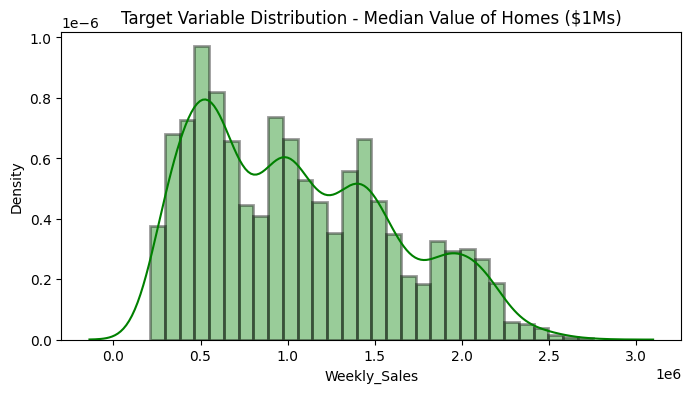

In [14]:
#Let us first analyze the distribution of the target variable

plt.figure(figsize=[8,4])
sns.distplot(df[target], color='g',hist_kws=dict(edgecolor="black", linewidth=2), bins=30)
plt.title('Target Variable Distribution - Median Value of Homes ($1Ms)')
plt.show()

**Inference:**The Target Variable seems to be be normally distributed, averaging around 20 units.

                               Visualising Categorical Features:                                


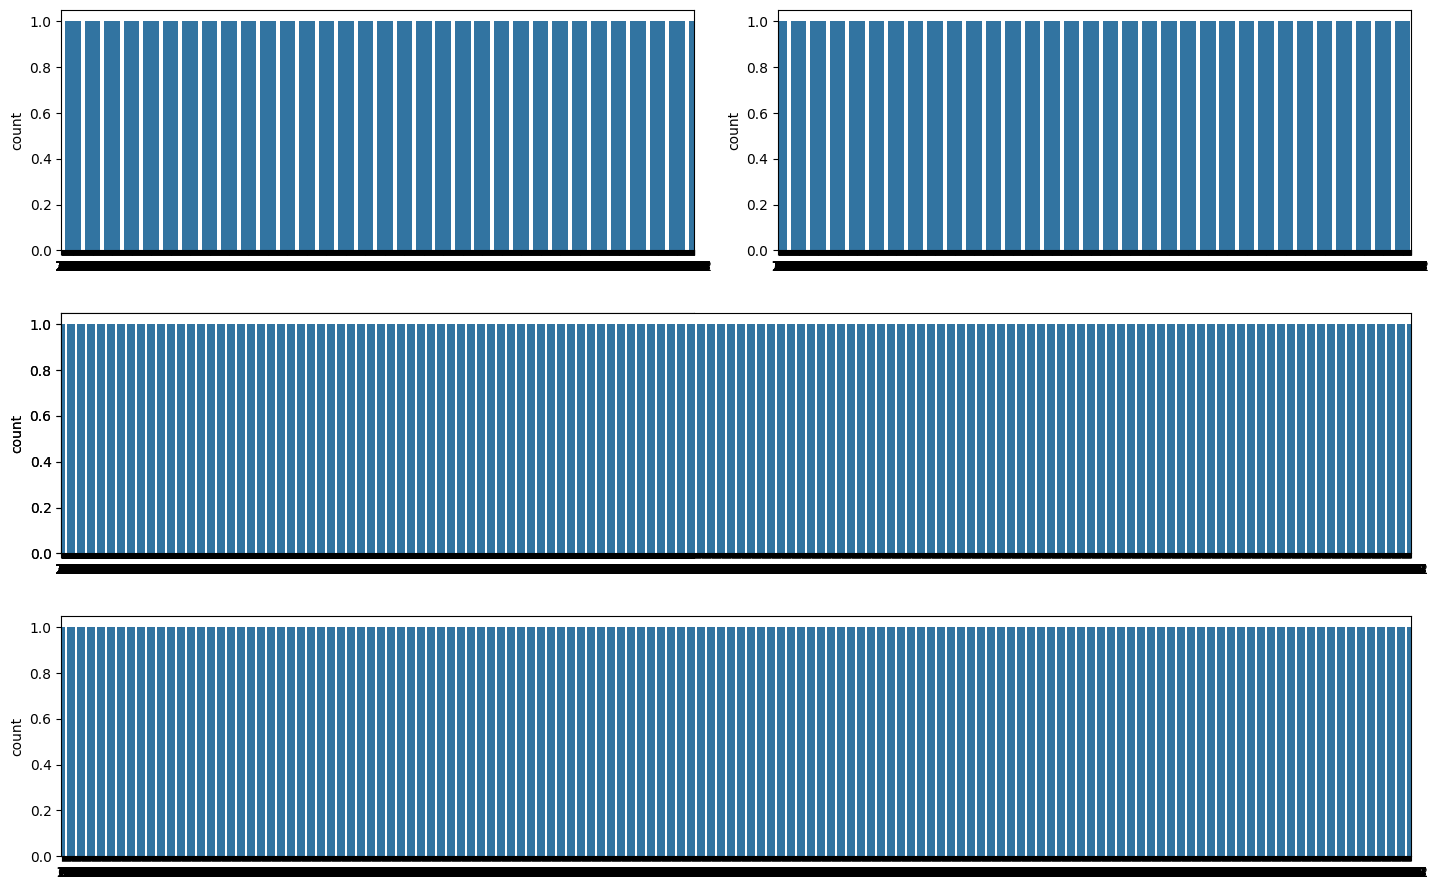

In [15]:
#Visualising the categorical features

print('\033[1mVisualising Categorical Features:'.center(100))

n=2
plt.figure(figsize=[15,3*math.ceil(len(cf)/n)])

for i in range(len(cf)):
    if df[cf[i]].nunique()<=8:
        plt.subplot(math.ceil(len(cf)/n),n,i+1)
        sns.countplot(df[cf[i]])
    else:
        plt.subplot(3,1,i-1)
        sns.countplot(df[cf[i]])

plt.tight_layout()
plt.show()

**Inference:** There are no categorical features in the dataset.

                                                Numeric Features Distribution                                                 


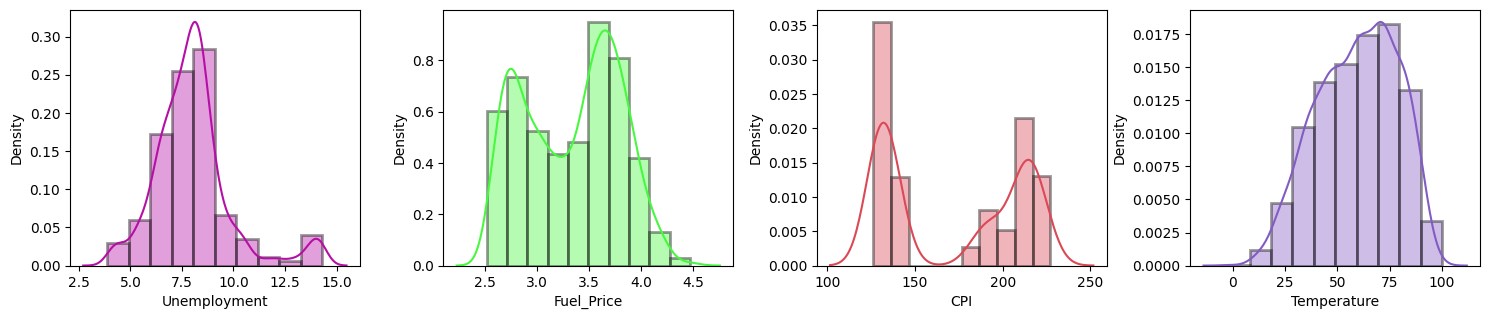

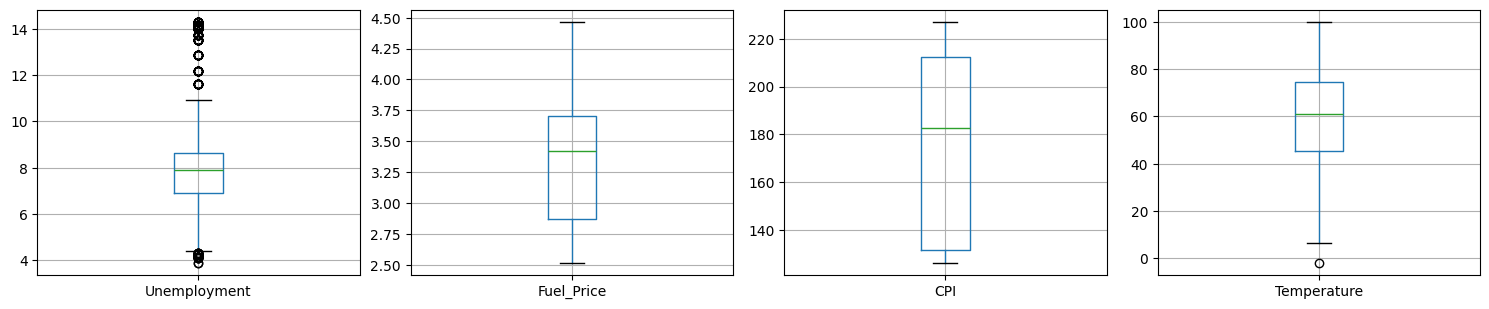

In [16]:
#Visualising the numeric features

print('\033[1mNumeric Features Distribution'.center(130))

n=4

clr=['r','g','b','g','b','r']

plt.figure(figsize=[15,6*math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/3),n,i+1)
    sns.distplot(df[nf[i]],hist_kws=dict(edgecolor="black", linewidth=2), bins=10, color=list(np.random.randint([255,255,255])/255))
plt.tight_layout()
plt.show()

plt.figure(figsize=[15,6*math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/3),n,i+1)
    df.boxplot(nf[i])
plt.tight_layout()
plt.show()

**Inference:** There seem to be some outliers. let us fix these in the upcoming section...

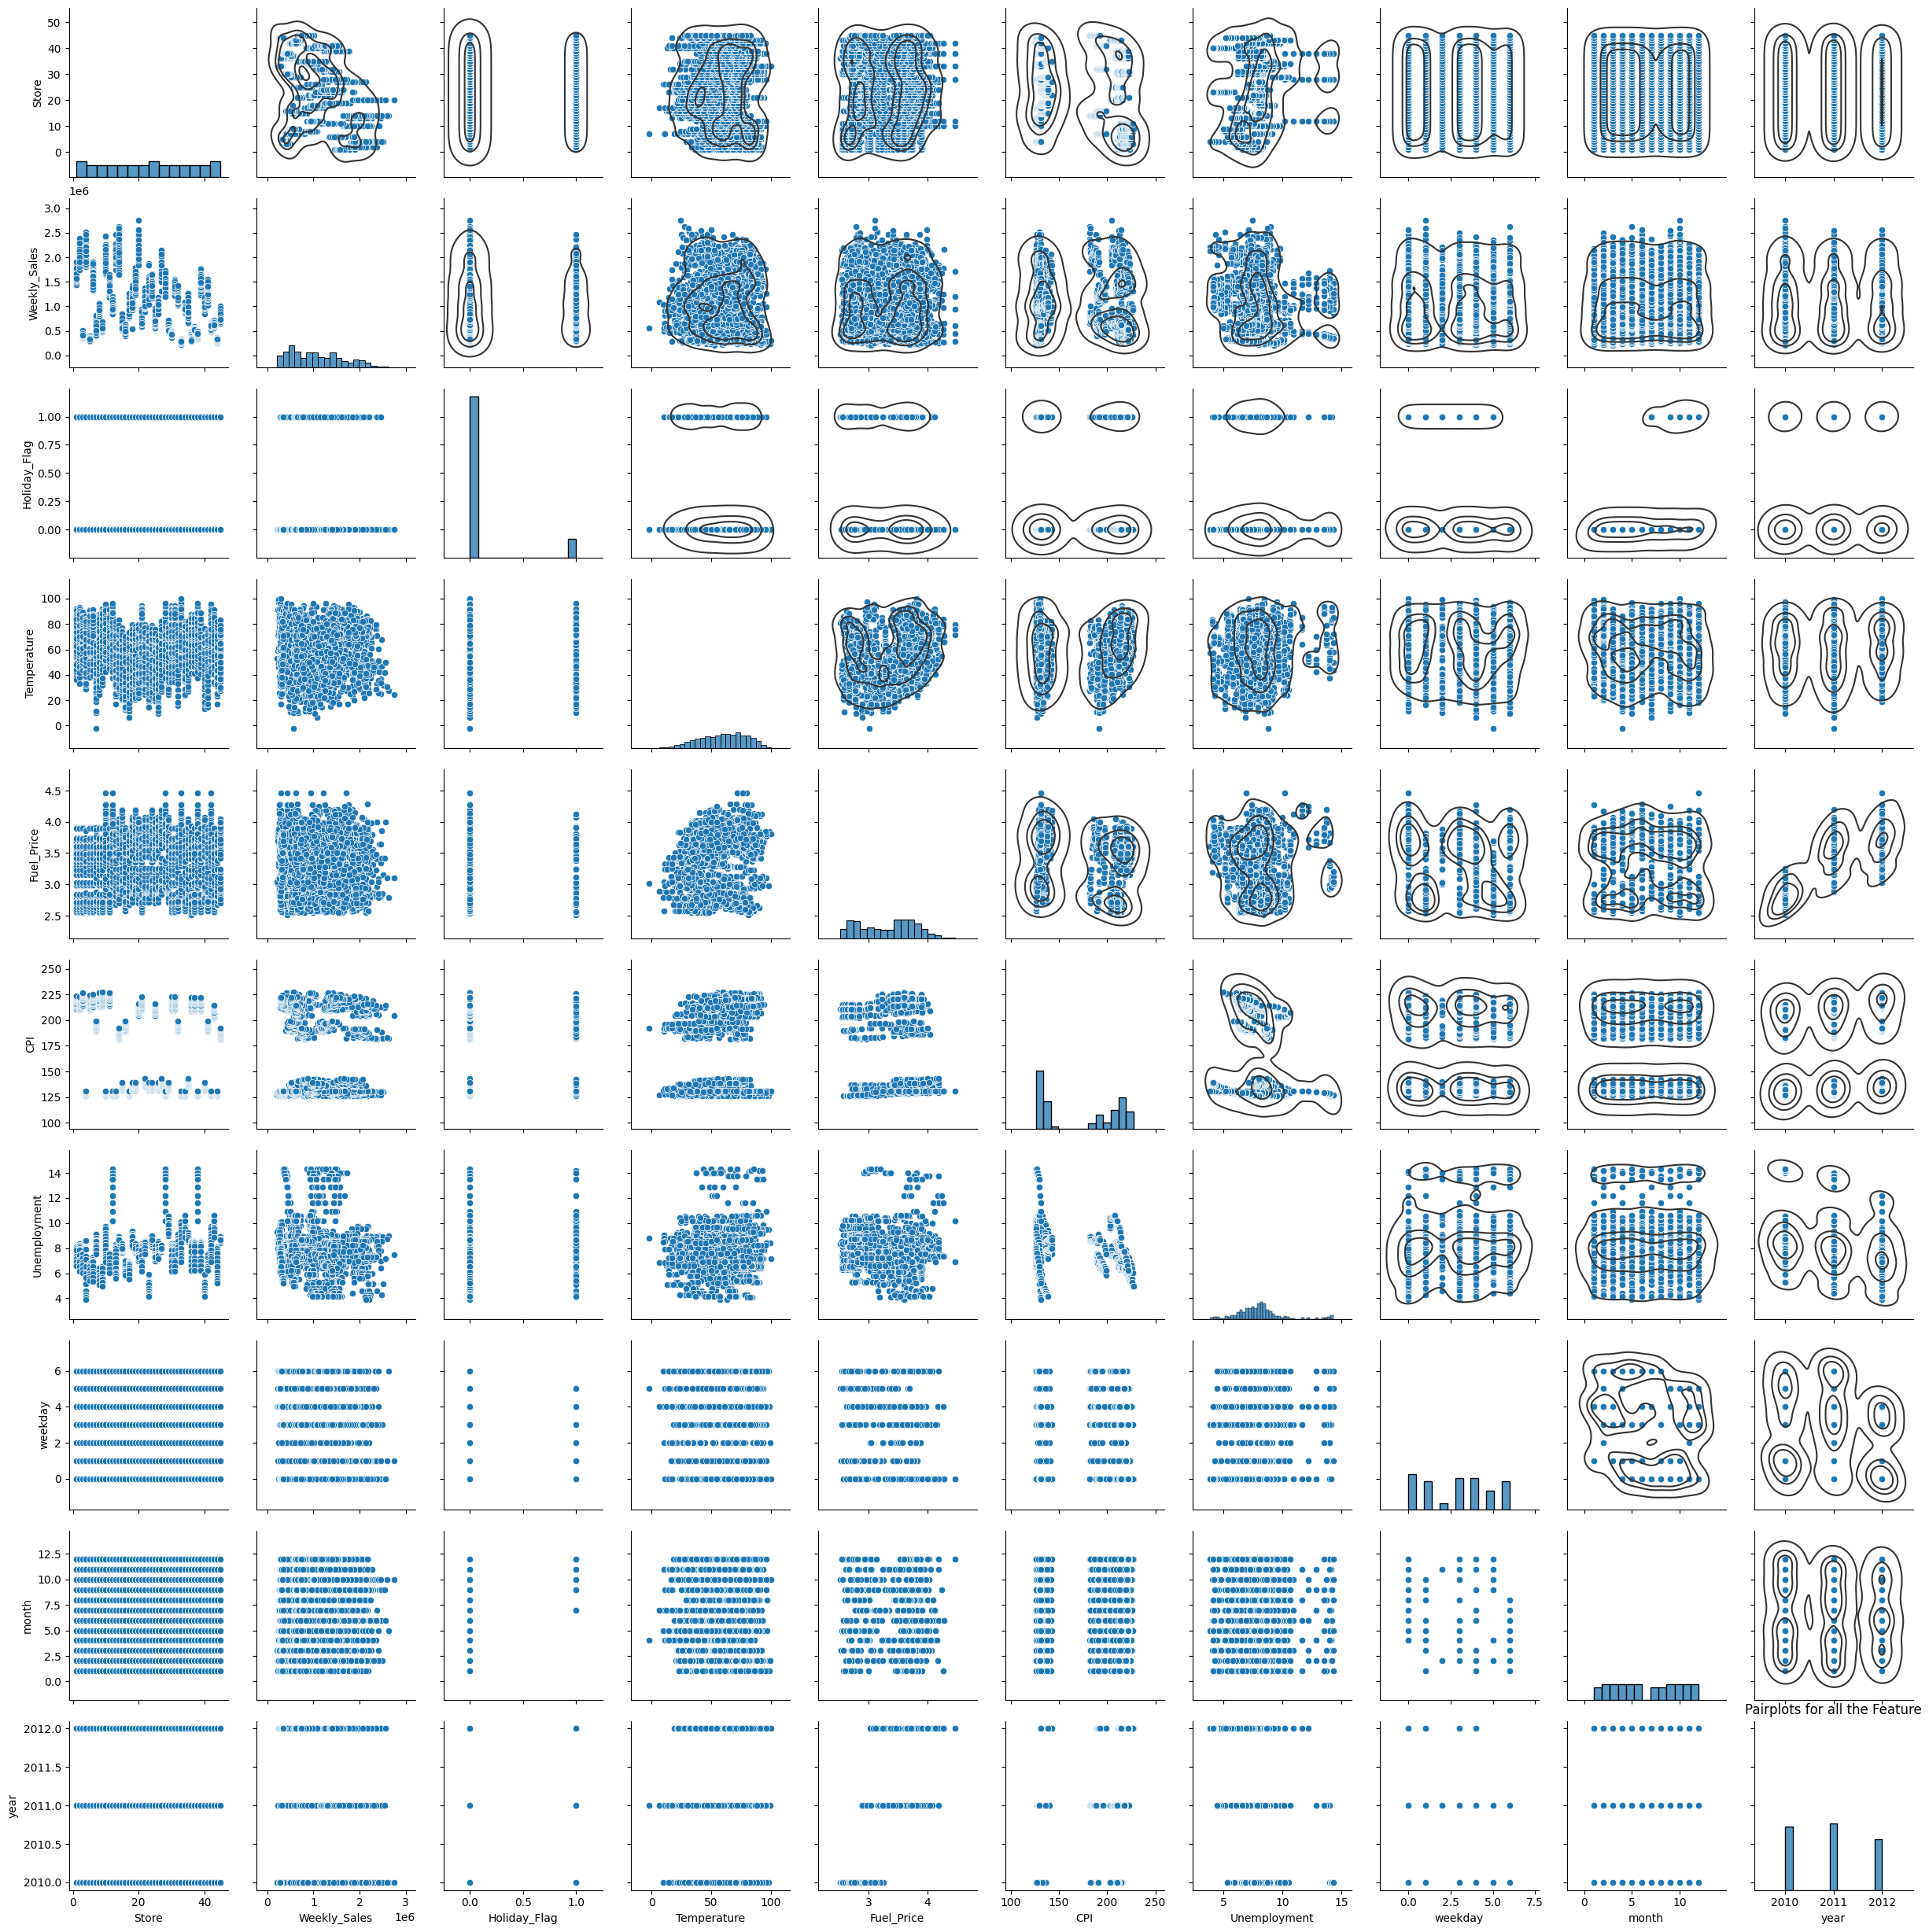

In [17]:
#Understanding the relationship between all the features

g = sns.pairplot(df)
plt.title('Pairplots for all the Feature')
g.map_upper(sns.kdeplot, levels=4, color=".2")
plt.show()

**Inference:** We can notice that some features have linear relationship, let us futher analyze the detect multicollinearity.

---

# <center> 3. Data Preprocessing

In [18]:
#Removal of any Duplicate rows (if any)

counter = 0
rs,cs = original_df.shape

df.drop_duplicates(inplace=True)

if df.shape==(rs,cs):
    print('\n\033[1mInference:\033[0m The dataset doesn\'t have any duplicates')
else:
    print(f'\n\033[1mInference:\033[0m Number of duplicates dropped/fixed ---> {rs-df.shape[0]}')


Inference: The dataset doesn't have any duplicates


In [19]:
#Check for empty elements

nvc = pd.DataFrame(df.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(nvc['Total Null Values']/df.shape[0],3)*100
print(nvc)

              Total Null Values  Percentage
Store                         0         0.0
Weekly_Sales                  0         0.0
Holiday_Flag                  0         0.0
Temperature                   0         0.0
Fuel_Price                    0         0.0
CPI                           0         0.0
Unemployment                  0         0.0
weekday                       0         0.0
month                         0         0.0
year                          0         0.0


**Inference:** The datset doesn't have any inconsistant values.

In [20]:
#Converting categorical Columns to Numeric

df3 = df.copy()

ecc = nvc[nvc['Percentage']!=0].index.values
fcc = [i for i in cf if i not in ecc]
#One-Hot Binay Encoding
oh=True
dm=True
for i in fcc:
    #print(i)
    if df3[i].nunique()==2:
        if oh==True: print("\033[1mOne-Hot Encoding on features:\033[0m")
        print(i);oh=False
        df3[i]=pd.get_dummies(df3[i], drop_first=True, prefix=str(i))
    if (df3[i].nunique()>2):
        if dm==True: print("\n\033[1mDummy Encoding on features:\033[0m")
        print(i);dm=False
        df3 = pd.concat([df3.drop([i], axis=1), pd.DataFrame(pd.get_dummies(df3[i], drop_first=True, prefix=str(i)))],axis=1)

df3.shape

One-Hot Encoding on features:
Holiday_Flag

Dummy Encoding on features:
year
weekday
month
Store


(2565, 69)

In [21]:
#Removal of outlier:

df1 = df3.copy()

#features1 = [i for i in features if i not in ['CHAS','RAD']]
features1 = nf

for i in features1:
    Q1 = df1[i].quantile(0.25)
    Q3 = df1[i].quantile(0.75)
    IQR = Q3 - Q1
    df1 = df1[df1[i] <= (Q3+(1.5*IQR))]
    df1 = df1[df1[i] >= (Q1-(1.5*IQR))]
    df1 = df1.reset_index(drop=True)
display(df1.head())
print('\n\033[1mInference:\033[0m\nBefore removal of outliers, The dataset had {} samples.'.format(df3.shape[0]))
print('After removal of outliers, The dataset now has {} samples.'.format(df1.shape[0]))

,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year_2011,year_2012,weekday_1,weekday_2,...,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
0,1643690.90,False,42.31,2.572,211.096358,8.106,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1641957.44,True,38.51,2.548,211.242170,8.106,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1554806.68,False,46.50,2.625,211.350143,8.106,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1439541.59,False,57.79,2.667,211.380643,8.106,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1594968.28,False,62.27,2.719,210.820450,7.808,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Inference:
Before removal of outliers, The dataset had 2565 samples.
After removal of outliers, The dataset now has 2368 samples.


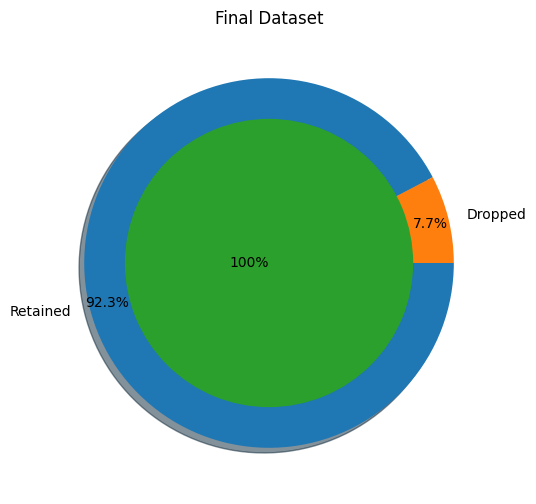


Inference: After the cleanup process, 197 samples were dropped, while retaining 7.68% of the data.


In [22]:
#Final Dataset size after performing Preprocessing

df = df1.copy()
df.columns=[i.replace('-','_') for i in df.columns]

plt.title('Final Dataset')
plt.pie([df.shape[0], original_df.shape[0]-df.shape[0]], radius = 1, labels=['Retained','Dropped'], counterclock=False,
        autopct='%1.1f%%', pctdistance=0.9, explode=[0,0], shadow=True)
plt.pie([df.shape[0]], labels=['100%'], labeldistance=-0, radius=0.78)
plt.show()

print(f'\n\033[1mInference:\033[0m After the cleanup process, {original_df.shape[0]-df.shape[0]} samples were dropped, \
while retaining {round(100 - (df.shape[0]*100/(original_df.shape[0])),2)}% of the data.')

---

# <center> 4. Data Manipulation

In [23]:
#Splitting the data intro training & testing sets

m=[]
for i in df.columns.values:
    m.append(i.replace(' ','_'))

df.columns = m
X = df.drop([target],axis=1)
Y = df[target]
Train_X, Test_X, Train_Y, Test_Y = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=100)
Train_X.reset_index(drop=True,inplace=True)

print('Original set  ---> ',X.shape,Y.shape,'\nTraining set  ---> ',Train_X.shape,Train_Y.shape,'\nTesting set   ---> ', Test_X.shape,'', Test_Y.shape)

Original set  --->  (2368, 68) (2368,) 
Training set  --->  (1894, 68) (1894,) 
Testing set   --->  (474, 68)  (474,)


In [24]:
#Feature Scaling (Standardization)

std = StandardScaler()

print('\033[1mStandardardization on Training set'.center(120))
Train_X_std = std.fit_transform(Train_X)
Train_X_std = pd.DataFrame(Train_X_std, columns=X.columns)
display(Train_X_std.describe())

print('\n','\033[1mStandardardization on Testing set'.center(120))
Test_X_std = std.transform(Test_X)
Test_X_std = pd.DataFrame(Test_X_std, columns=X.columns)
display(Test_X_std.describe())

                                         Standardardization on Training set                                         


,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year_2011,year_2012,weekday_1,weekday_2,weekday_3,...,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
count,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,...,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03,1.894000e+03
mean,-1.594407e-17,9.941596e-17,8.065823e-17,3.563968e-17,1.012917e-16,1.219252e-16,1.969561e-17,-7.690668e-17,1.406830e-17,-2.626082e-17,...,6.940359e-17,3.188814e-17,2.813659e-17,-1.805431e-17,2.438505e-17,4.689432e-17,2.063350e-17,-2.907448e-17,3.751546e-17,3.563968e-17
std,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,...,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00,1.000264e+00
min,-3.540782e-01,-2.757520e+00,-1.718763e+00,-1.268924e+00,-2.688744e+00,-7.544400e-01,-6.192670e-01,-4.440931e-01,-1.987889e-01,-4.568140e-01,...,-1.542199e-01,-1.612519e-01,-5.637345e-02,-1.560047e-01,-1.310947e-01,-1.595201e-01,-1.595201e-01,-1.663499e-01,-1.524162e-01,-1.449974e-01
25%,-3.540782e-01,-7.666527e-01,-1.003618e+00,-1.097471e+00,-6.834318e-01,-7.544400e-01,-6.192670e-01,-4.440931e-01,-1.987889e-01,-4.568140e-01,...,-1.542199e-01,-1.612519e-01,-5.637345e-02,-1.560047e-01,-1.310947e-01,-1.595201e-01,-1.595201e-01,-1.663499e-01,-1.524162e-01,-1.449974e-01
50%,-3.540782e-01,8.099067e-02,1.784471e-01,3.910706e-01,9.645700e-02,-7.544400e-01,-6.192670e-01,-4.440931e-01,-1.987889e-01,-4.568140e-01,...,-1.542199e-01,-1.612519e-01,-5.637345e-02,-1.560047e-01,-1.310947e-01,-1.595201e-01,-1.595201e-01,-1.663499e-01,-1.524162e-01,-1.449974e-01
75%,-3.540782e-01,8.002624e-01,8.050184e-01,9.805640e-01,6.174649e-01,1.325486e+00,1.614812e+00,-4.440931e-01,-1.987889e-01,-4.568140e-01,...,-1.542199e-01,-1.612519e-01,-5.637345e-02,-1.560047e-01,-1.310947e-01,-1.595201e-01,-1.595201e-01,-1.663499e-01,-1.524162e-01,-1.449974e-01
max,2.824235e+00,2.134414e+00,2.556794e+00,1.324014e+00,2.591127e+00,1.325486e+00,1.614812e+00,2.251780e+00,5.030463e+00,2.189075e+00,...,6.484247e+00,6.201478e+00,1.773885e+01,6.410062e+00,7.628073e+00,6.268802e+00,6.268802e+00,6.011427e+00,6.560984e+00,6.896673e+00



                                          Standardardization on Testing set                                          


,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year_2011,year_2012,weekday_1,weekday_2,weekday_3,...,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,...,474.000000,474.000000,4.740000e+02,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,-0.092571,0.020221,0.108648,-0.084255,0.029846,0.096838,-0.044251,-0.080093,-0.066403,0.045570,...,0.027848,-0.040441,-5.637345e-02,0.010225,0.016231,-0.023902,-0.023902,-0.088150,0.045870,0.122408
std,0.874287,0.968470,1.023572,1.003402,0.987228,1.023783,0.977755,0.922277,0.822302,1.038816,...,1.085351,0.869304,7.154612e-16,1.032517,1.060091,0.924777,0.924777,0.691371,1.137799,1.347332
min,-0.354078,-2.533358,-1.661901,-1.268924,-2.688744,-0.754440,-0.619267,-0.444093,-0.198789,-0.456814,...,-0.154220,-0.161252,-5.637345e-02,-0.156005,-0.131095,-0.159520,-0.159520,-0.166350,-0.152416,-0.144997
25%,-0.354078,-0.746843,-0.981749,-1.094236,-0.600249,-0.754440,-0.619267,-0.444093,-0.198789,-0.456814,...,-0.154220,-0.161252,-5.637345e-02,-0.156005,-0.131095,-0.159520,-0.159520,-0.166350,-0.152416,-0.144997
50%,-0.354078,0.137552,0.342471,0.205175,0.170307,-0.754440,-0.619267,-0.444093,-0.198789,-0.456814,...,-0.154220,-0.161252,-5.637345e-02,-0.156005,-0.131095,-0.159520,-0.159520,-0.166350,-0.152416,-0.144997
75%,-0.354078,0.764553,0.952093,0.952224,0.639376,1.325486,1.614812,-0.444093,-0.198789,-0.456814,...,-0.154220,-0.161252,-5.637345e-02,-0.156005,-0.131095,-0.159520,-0.159520,-0.166350,-0.152416,-0.144997
max,2.824235,1.760117,2.556794,1.329048,2.591127,1.325486,1.614812,2.251780,5.030463,2.189075,...,6.484247,6.201478,-5.637345e-02,6.410062,7.628073,6.268802,6.268802,6.011427,6.560984,6.896673


---

# <center> 5. Feature Selection/Extraction

                                       Correlation Matrix                                       


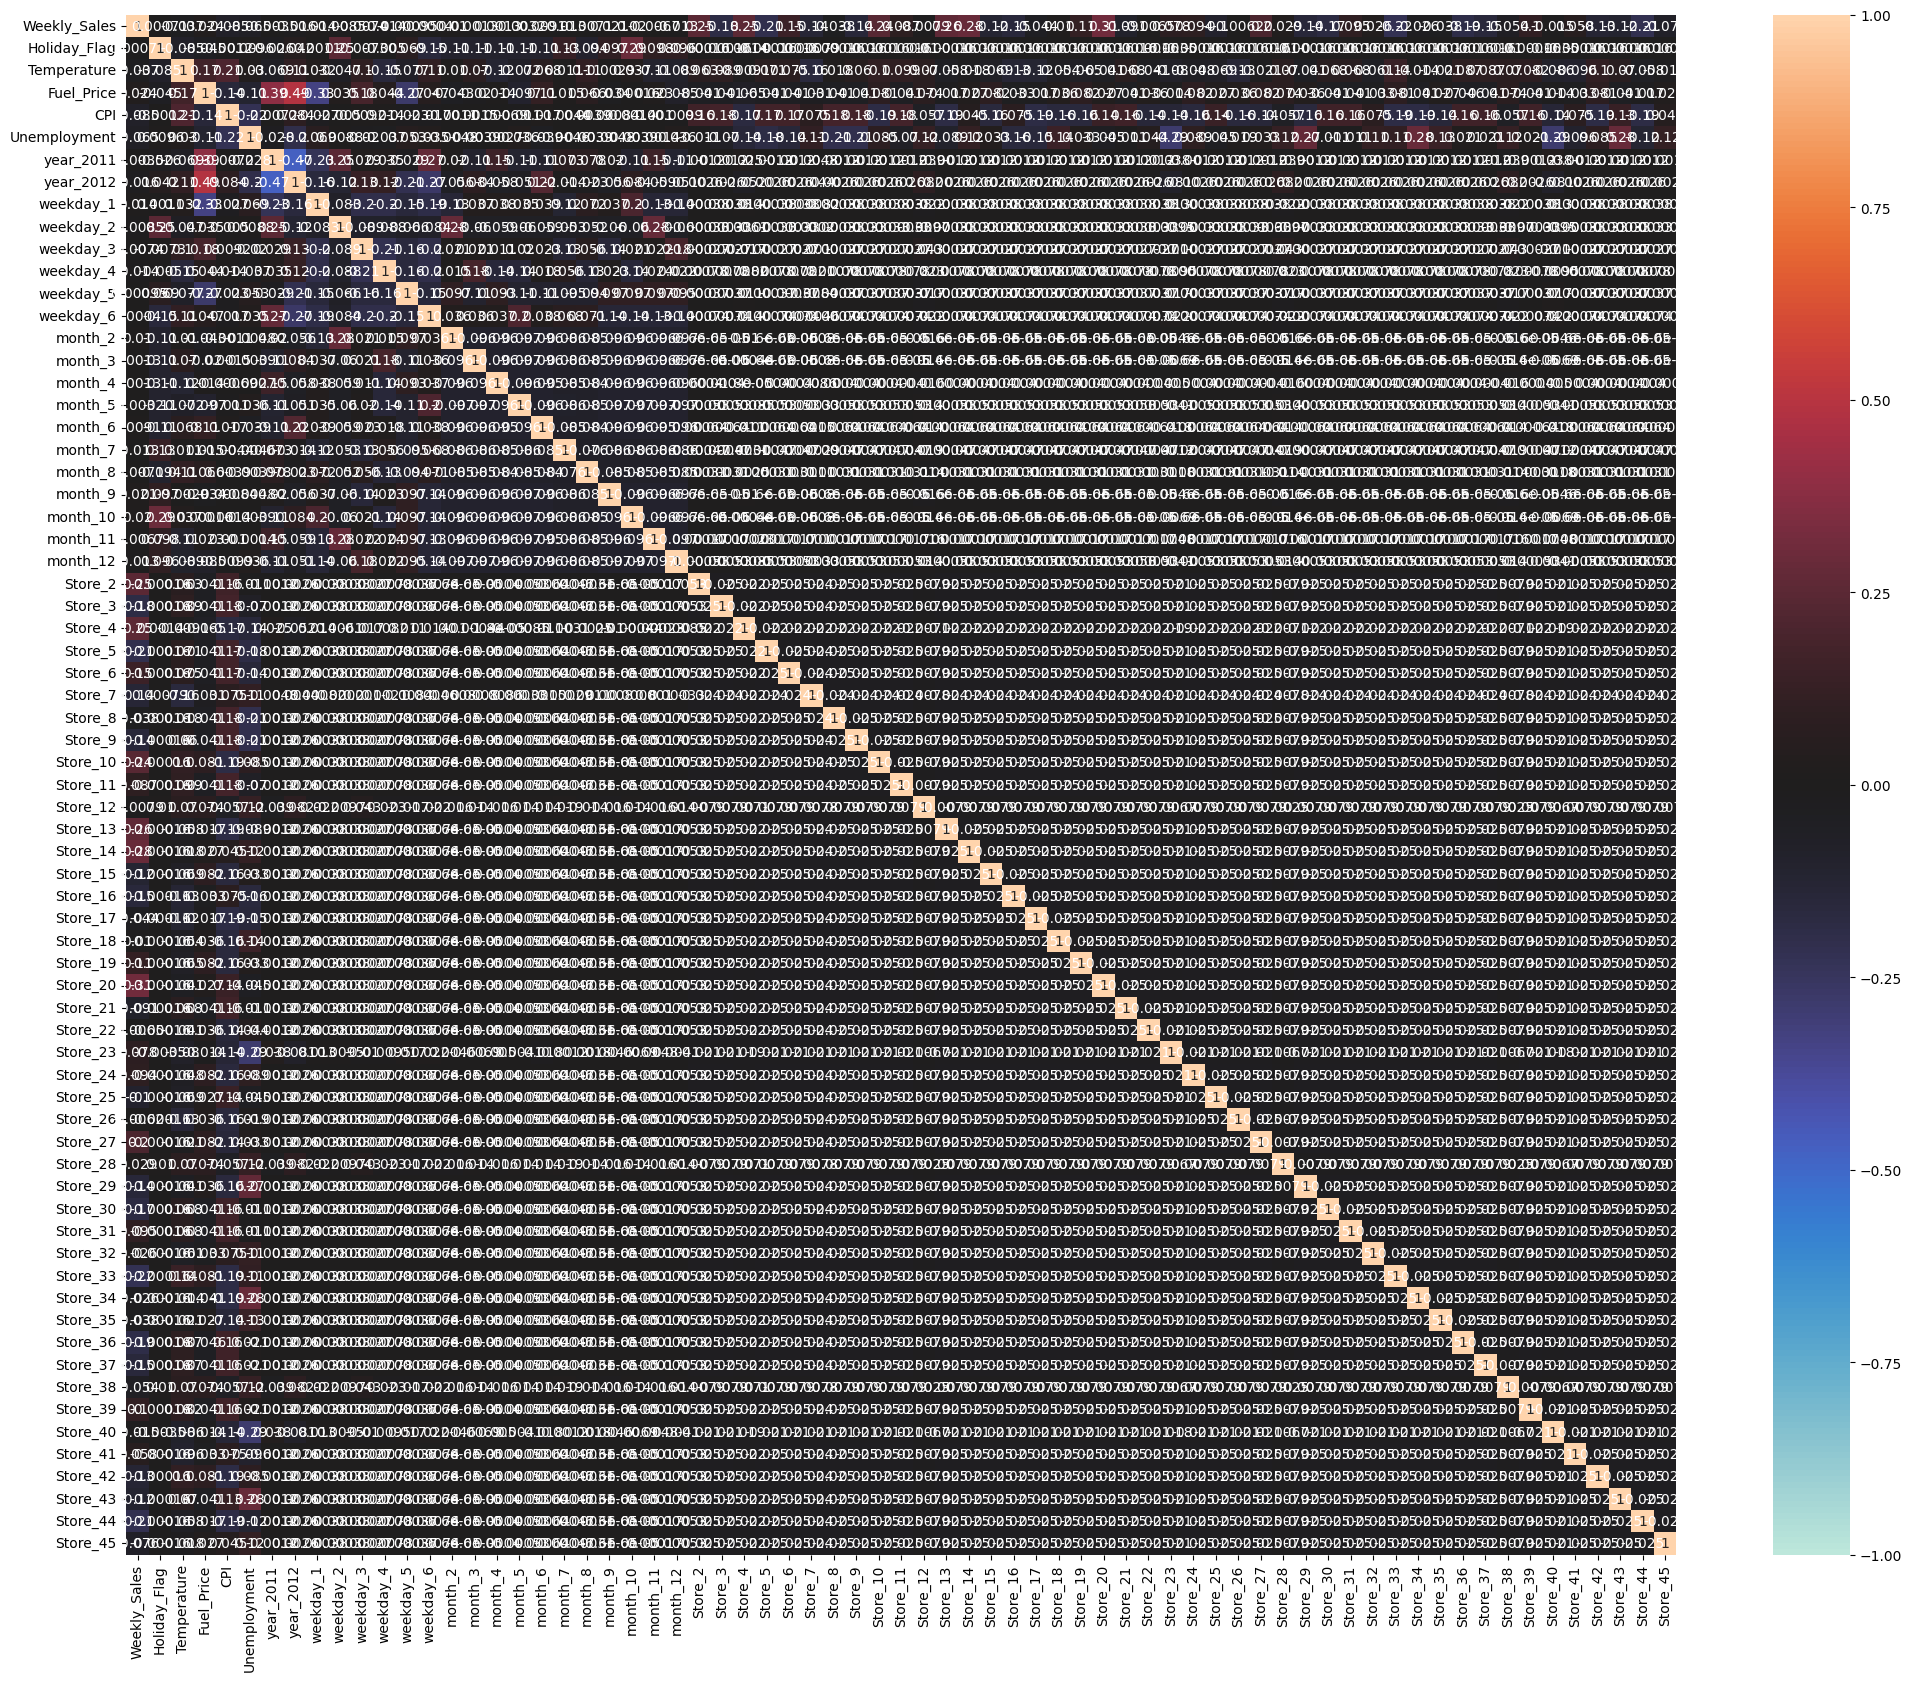

In [25]:
#Checking the correlation

print('\033[1mCorrelation Matrix'.center(100))
plt.figure(figsize=[25,20])
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, center=0) #cmap='BuGn'
plt.show()

**Inference:** There seems to be strong multi-correlation between the features. Let us try to fix these...

In [26]:
#Testing a Linear Regression model with statsmodels

Train_xy = pd.concat([Train_X_std,Train_Y.reset_index(drop=True)],axis=1)
a = Train_xy.columns.values

API = api.ols(formula='{} ~ {}'.format(target,' + '.join(i for i in Train_X.columns)), data=Train_xy).fit()
#print(API.conf_int())
#print(API.pvalues)
API.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Weekly_Sales   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     916.2
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        05:54:23   Log-Likelihood:                -24399.
No. Observations:                1894   AIC:                         4.894e+04
Df Residuals:                    1825   BIC:                         4.932e+04
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.061e+06   2227.600    476.273      0.000    1.06e+06    1.07e+06
Holiday_Flag  2510.3551   2708.962      0.927      0.354   -2802.636    7823.346
Temperature  -8442.6152   3243.262     -2.603      0.009   -1.48e+04   -2081.720
Fuel_Price    1.131e+04   6491.783      1.743      0.082   -1419.934     2.4e+04
CPI           3.537e+05   6.83e+04      5.176      0.000     2.2e+05    4.88e+05
Unemployment -4.662e+04   7585.433     -6.146      0.000   -6.15e+04   -3.17e+04
year_2011    -4.001e+04   7027.235     -5.693      0.000   -5.38e+04   -2.62e+04
year_2012    -6.664e+04   8855.275     -7.526      0.000    -8.4e+04   -4.93e+04
weekday_1    -8815.9418   3476.579     -2.536      0.011   -1.56e+04   -1997.450
weekday_2    -9102.2792   3225.106     -2.822      0.005   -1.54e+04   -2776.992
weekday_3    -5876.1995   3216.233     -1.827      0.068   -1.22e+04     431.685
weekday_4    -1.191e+04   3388.677     -3.514      0.000   -1.86e+04   -5260.594
weekday_5    -1.443e+04   3208.102     -4.497      0.000   -2.07e+04   -8133.696
weekday_6    -7360.1733   3484.403     -2.112      0.035   -1.42e+04    -526.336
month_2       1.515e+04   3544.122      4.274      0.000    8195.275    2.21e+04
month_3       1.192e+04   3305.982      3.605      0.000    5435.244    1.84e+04
month_4       1.104e+04   3481.006      3.172      0.002    4214.245    1.79e+04
month_5       2091.6776   3572.976      0.585      0.558   -4915.874    9099.229
month_6       1.736e+04   3315.720      5.236      0.000    1.09e+04    2.39e+04
month_7       1347.0683   3249.586      0.415      0.679   -5026.231    7720.367
month_8       5507.1723   3223.422      1.708      0.088    -814.812    1.18e+04
month_9       1.745e+04   3505.265      4.978      0.000    1.06e+04    2.43e+04
month_10      2.064e+04   3668.311      5.626      0.000    1.34e+04    2.78e+04
month_11      8972.4435   3548.669      2.528      0.012    2012.565    1.59e+04
month_12     -1347.2525   3626.145     -0.372      0.710   -8459.082    5764.577
Store_2       5.468e+04   3133.907     17.449      0.000    4.85e+04    6.08e+04
Store_3       -1.93e+05   3320.584    -58.129      0.000      -2e+05   -1.87e+05
Store_4       1.679e+05   2.17e+04      7.739      0.000    1.25e+05    2.11e+05
Store_5      -1.906e+05   3241.580    -58.805      0.000   -1.97e+05   -1.84e+05
Store_6      -7881.9935   3299.179     -2.389      0.017   -1.44e+04   -1411.431
Store_7      -1.184e+05   6401.250    -18.497      0.000   -1.31e+05   -1.06e+05
Store_8      -1.152e+05   3491.822    -32.982      0.000   -1.22e+05   -1.08e+05
Store_9       -1.75e+05   3529.444    -49.593      0.000   -1.82e+05   -1.68e+05
Store_10      1.706e+05    2.3e+04      7.423      0.000    1.25e+05    2.16e+05
Store_11     -4.361e+04   3365.213    -12.959      0.000   -5.02e+04    -3.7e+04
Store

 ---

**Approach:**
We can fix these multicollinearity with two techniques:
1. Manual Method - Variance Inflation Factor (VIF)
2. Automatic Method - Recursive Feature Elimination (RFE)
3. Feature Elmination using PCA Decomposition

## 5a. Manual Method - VIF

Dropped Features -->  ['CPI', 'Unemployment', 'Fuel_Price', 'month_10', 'weekday_1', 'Store_16', 'year_2011', 'month_2', 'Temperature', 'Store_11', 'weekday_6', 'month_5', 'Store_31', 'weekday_2', 'month_3', 'Store_25', 'weekday_3', 'year_2012', 'Store_32', 'month_4', 'Store_43', 'Store_3', 'weekday_5', 'Store_6', 'month_11', 'Store_2', 'Store_39', 'month_6', 'Store_17', 'Store_27', 'Holiday_Flag', 'Store_19', 'month_8', 'Store_7', 'Store_10', 'Store_9', 'Store_5', 'Store_8', 'Store_14', 'Store_26', 'month_7', 'Store_15', 'Store_13', 'Store_4', 'Store_21', 'Store_30', 'weekday_4', 'month_9', 'Store_20', 'Store_18', 'Store_23', 'Store_22', 'Store_24', 'Store_34', 'Store_33', 'Store_35', 'Store_29']


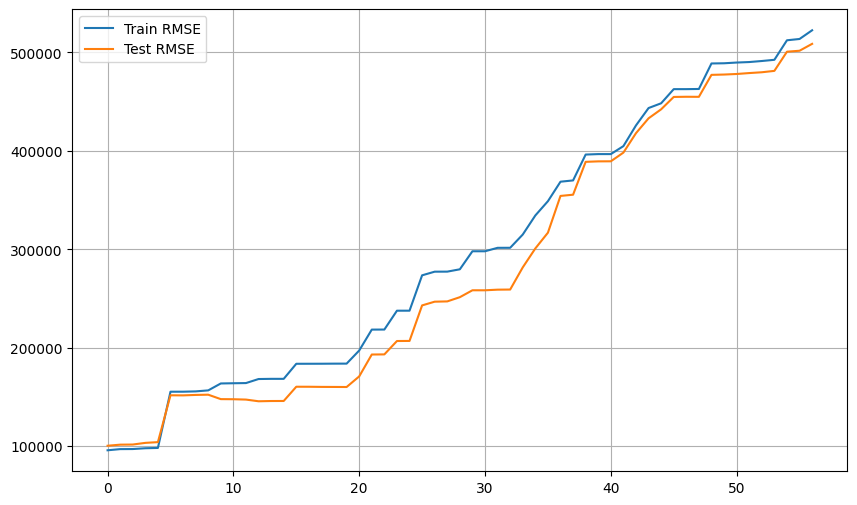

In [27]:
from sklearn.preprocessing import PolynomialFeatures
Trr=[]; Tss=[]; n=3
order=['ord-'+str(i) for i in range(2,n)]
#Trd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
#Tsd = pd.DataFrame(np.zeros((10,n-2)), columns=order)

DROP=[];b=[]

for i in range(len(Train_X_std.columns)):
    vif = pd.DataFrame()
    X = Train_X_std.drop(DROP,axis=1)
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    vif.reset_index(drop=True, inplace=True)
    if vif.loc[0][1]>1:
        DROP.append(vif.loc[0][0])
        LR = LinearRegression()
        LR.fit(Train_X_std.drop(DROP,axis=1), Train_Y)

        pred1 = LR.predict(Train_X_std.drop(DROP,axis=1))
        pred2 = LR.predict(Test_X_std.drop(DROP,axis=1))

        Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))
        Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

        #Trd.loc[i,'ord-'+str(k)] = round(np.sqrt(mean_squared_error(Train_Y, pred1)),2)
        #Tsd.loc[i,'ord-'+str(k)] = round(np.sqrt(mean_squared_error(Test_Y, pred2)),2)

print('Dropped Features --> ',DROP)
#plt.plot(b)
#plt.show()
#print(API.summary())

# plt.figure(figsize=[20,4])
# plt.subplot(1,3,1)
# sns.heatmap(Trd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max())
# plt.title('Train RMSE')
# plt.subplot(1,3,2)
# sns.heatmap(Tsd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+10)
# plt.title('Test RMSE')
# plt.subplot(1,3,3)
# sns.heatmap((Trd+Tsd).loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+25)
# plt.title('Total RMSE')
# plt.show()

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
#plt.ylim([19.75,20.75])
plt.legend()
plt.grid()
plt.show()

## 5b. Automatic Method - RFE

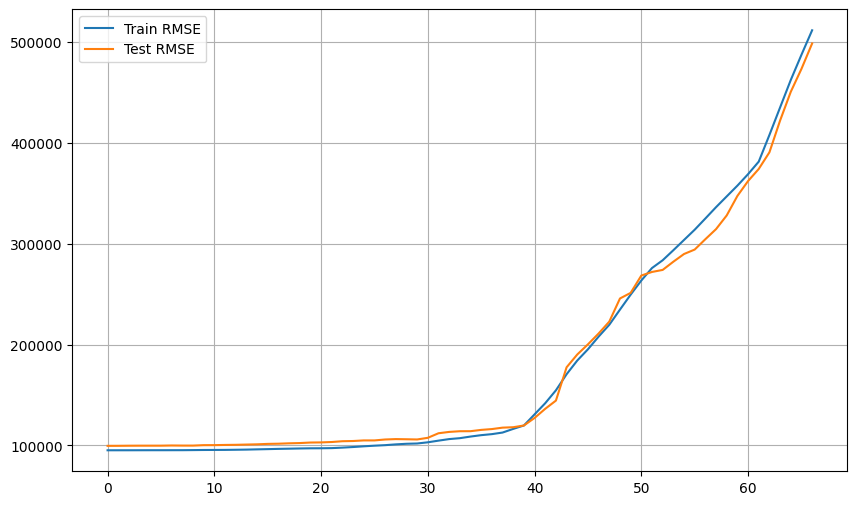

In [28]:
from sklearn.preprocessing import PolynomialFeatures
Trr=[]; Tss=[]; n=3
order=['ord-'+str(i) for i in range(2,n)]
Trd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
Tsd = pd.DataFrame(np.zeros((10,n-2)), columns=order)

m=df.shape[1]-2
for i in range(m):
    lm = LinearRegression()
    rfe = RFE(lm,n_features_to_select=Train_X_std.shape[1]-i)             # running RFE
    rfe = rfe.fit(Train_X_std, Train_Y)

    LR = LinearRegression()
    LR.fit(Train_X_std.loc[:,rfe.support_], Train_Y)

    pred1 = LR.predict(Train_X_std.loc[:,rfe.support_])
    pred2 = LR.predict(Test_X_std.loc[:,rfe.support_])

    Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))
    Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

# plt.figure(figsize=[20,4])
# plt.subplot(1,3,1)
# sns.heatmap(Trd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max())
# plt.title('Train RMSE')
# plt.subplot(1,3,2)
# sns.heatmap(Tsd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+10)
# plt.title('Test RMSE')
# plt.subplot(1,3,3)
# sns.heatmap((Trd+Tsd).loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+25)
# plt.title('Total RMSE')
# plt.show()

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
#plt.ylim([19.75,20.75])
plt.legend()
plt.grid()
plt.show()

## 5c. Feature Elmination using PCA Decomposition

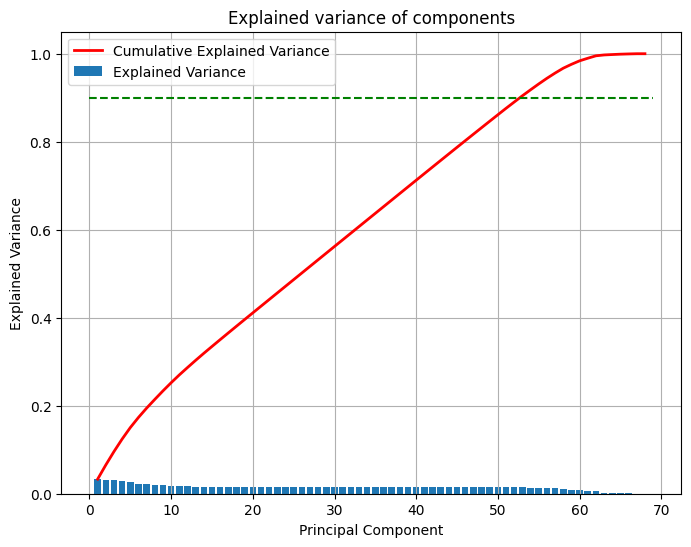

In [29]:
from sklearn.decomposition import PCA

pca = PCA().fit(Train_X_std)

fig, ax = plt.subplots(figsize=(8,6))
x_values = range(1, pca.n_components_+1)
ax.bar(x_values, pca.explained_variance_ratio_, lw=2, label='Explained Variance')
ax.plot(x_values, np.cumsum(pca.explained_variance_ratio_), lw=2, label='Cumulative Explained Variance', color='red')
plt.plot([0,pca.n_components_+1],[0.9,0.9],'g--')
ax.set_title('Explained variance of components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')
plt.legend()
plt.grid()
plt.show()

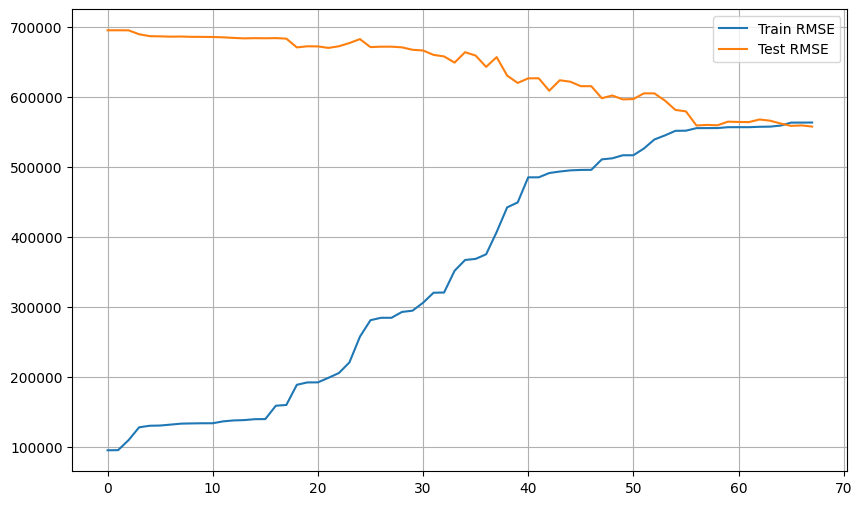

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
Trr=[]; Tss=[]; n=3
order=['ord-'+str(i) for i in range(2,n)]
Trd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
Tsd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
m=df.shape[1]-1

for i in range(m):
    pca = PCA(n_components=Train_X_std.shape[1]-i)
    Train_X_std_pca = pca.fit_transform(Train_X_std)
    Test_X_std_pca = pca.fit_transform(Test_X_std)

    LR = LinearRegression()
    LR.fit(Train_X_std_pca, Train_Y)

    pred1 = LR.predict(Train_X_std_pca)
    pred2 = LR.predict(Test_X_std_pca)

    Trr.append(round(np.sqrt(mean_squared_error(Train_Y, pred1)),2))
    Tss.append(round(np.sqrt(mean_squared_error(Test_Y, pred2)),2))

# plt.figure(figsize=[20,4.5])
# plt.subplot(1,3,1)
# sns.heatmap(Trd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max())
# plt.title('Train RMSE')
# plt.subplot(1,3,2)
# sns.heatmap(Tsd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+10)
# plt.title('Test RMSE')
# plt.subplot(1,3,3)
# sns.heatmap((Trd+Tsd).loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+25)
# plt.title('Total RMSE')
# plt.show()

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
#plt.ylim([19.5,20.75])
plt.legend()
plt.grid()
plt.show()

#### Inference:
It can be seen that the performance of the modelsis quiet comparable unpon dropping features using VIF, RFE & PCA Techniques. Comparing the RMSE plots, the optimal values were found for dropping most  features using manual RFE Technique. But let us skip these for now, as the advanced ML Algorithms take care of multicollinearity.

In [31]:
#Shortlisting the selected Features (with RFE)

lm = LinearRegression()
rfe = RFE(lm,n_features_to_select=Train_X_std.shape[1]-28)             # running RFE
rfe = rfe.fit(Train_X_std, Train_Y)

LR = LinearRegression()
LR.fit(Train_X_std.loc[:,rfe.support_], Train_Y)

#print(Train_X_std.loc[:,rfe.support_].columns)

pred1 = LR.predict(Train_X_std.loc[:,rfe.support_])
pred2 = LR.predict(Test_X_std.loc[:,rfe.support_])

print(np.sqrt(mean_squared_error(Train_Y, pred1)))
print(np.sqrt(mean_squared_error(Test_Y, pred2)))

Train_X_std = Train_X_std.loc[:,rfe.support_]
Test_X_std = Test_X_std.loc[:,rfe.support_]

101603.06866536771
106084.14346068593


---

# <center> 6. Predictive Modelling

In [32]:
#Let us first define a function to evaluate our models

Model_Evaluation_Comparison_Matrix = pd.DataFrame(np.zeros([5,8]), columns=['Train-R2','Test-R2','Train-RSS','Test-RSS',
                                                                            'Train-MSE','Test-MSE','Train-RMSE','Test-RMSE'])
rc=np.random.choice(Train_X_std.loc[:,Train_X_std.nunique()>=50].columns.values,2,replace=False)
def Evaluate(n, pred1,pred2):
    #Plotting predicted predicteds alongside the actual datapoints
    plt.figure(figsize=[15,6])
    for e,i in enumerate(rc):
        plt.subplot(2,3,e+1)
        plt.scatter(y=Train_Y, x=Train_X_std[i], label='Actual')
        plt.scatter(y=pred1, x=Train_X_std[i], label='Prediction')
        plt.legend()
    plt.show()

    #Evaluating the Multiple Linear Regression Model

    print('\n\n{}Training Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Training set --->',round(r2_score(Train_Y, pred1),20))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Train_Y-pred1)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Train_Y, pred1),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Train_Y, pred1)),20))

    print('\n{}Testing Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Testing set --->',round(r2_score(Test_Y, pred2),20))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Test_Y-pred2)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Test_Y, pred2),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Test_Y, pred2)),20))
    print('\n{}Residual Plots{}'.format('-'*20, '-'*20))

    Model_Evaluation_Comparison_Matrix.loc[n,'Train-R2']  = round(r2_score(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-R2']   = round(r2_score(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RSS'] = round(np.sum(np.square(Train_Y-pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RSS']  = round(np.sum(np.square(Test_Y-pred2)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-MSE'] = round(mean_squared_error(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-MSE']  = round(mean_squared_error(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RMSE']= round(np.sqrt(mean_squared_error(Train_Y, pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RMSE'] = round(np.sqrt(mean_squared_error(Test_Y, pred2)),20)

    # Plotting y_test and y_pred to understand the spread.
    plt.figure(figsize=[15,4])

    plt.subplot(1,2,1)
    sns.distplot((Train_Y - pred1))
    plt.title('Error Terms')
    plt.xlabel('Errors')

    plt.subplot(1,2,2)
    plt.scatter(Train_Y,pred1)
    plt.plot([Train_Y.min(),Train_Y.max()],[Train_Y.min(),Train_Y.max()], 'r--')
    plt.title('Test vs Prediction')
    plt.xlabel('y_test')
    plt.ylabel('y_pred')
    plt.show()

---

## Objective:
Let us now try building multiple regression models & compare their evaluation metrics to choose the best fit model both training and testing sets...

## 6a. Multiple Linear Regression(MLR)

<img src="https://raw.githubusercontent.com/Masterx-AI/Master-AI/main/3.%20Machine%20Learning/Z-Etc/Reg/mr.png" style="width: 600px;float: left;"/>

<<<----------------------------------- Evaluating Multiple Linear Regression Model ----------------------------------->>>

The Intercept of the Regresion Model was found to be  1060946.241494192


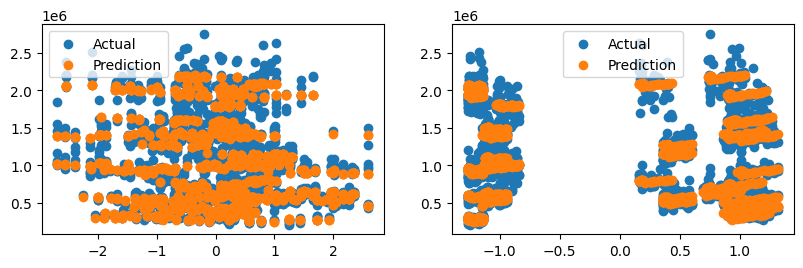



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.9675569056767866
Residual Sum of Squares (RSS) on Training set  ---> 19552109666843.59
Mean Squared Error (MSE) on Training set       ---> 10323183562.219425
Root Mean Squared Error (RMSE) on Training set ---> 101603.0686653677

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.9634571248347955
Residual Sum of Squares (RSS) on Training set  ---> 5334322764055.224
Mean Squared Error (MSE) on Training set       ---> 11253845493.787392
Root Mean Squared Error (RMSE) on Training set ---> 106084.14346068593

--------------------Residual Plots--------------------


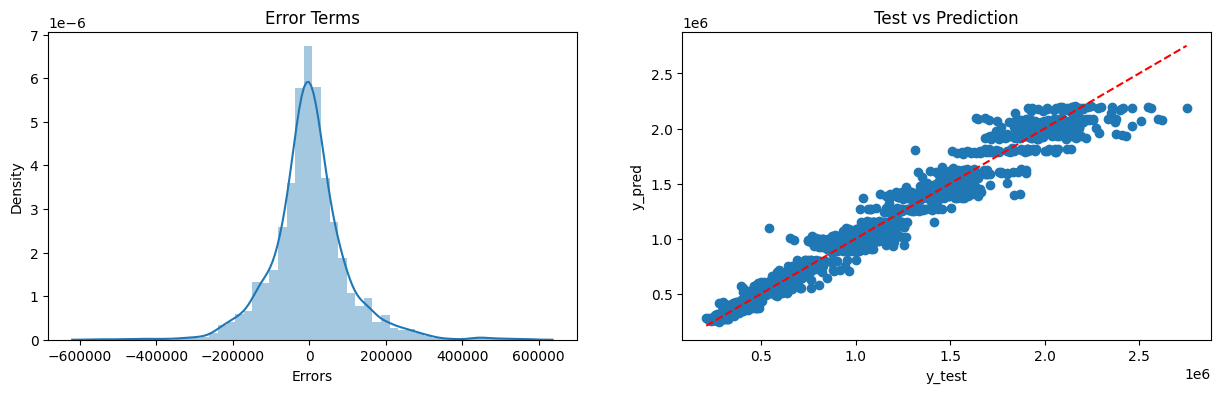

In [33]:
#Linear Regression

MLR = LinearRegression().fit(Train_X_std,Train_Y)
pred1 = MLR.predict(Train_X_std)
pred2 = MLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Multiple Linear Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
#print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(0, pred1, pred2)

---

## 6b. Ridge Regression Model

<img src="https://raw.githubusercontent.com/Masterx-AI/Master-AI/main/3.%20Machine%20Learning/Z-Etc/Reg/ridge.png" style="width: 500px;float: left;"/>

<<<----------------------------------- Evaluating Ridge Regression Model ----------------------------------->>>

The Intercept of the Regresion Model was found to be  1060946.241494192


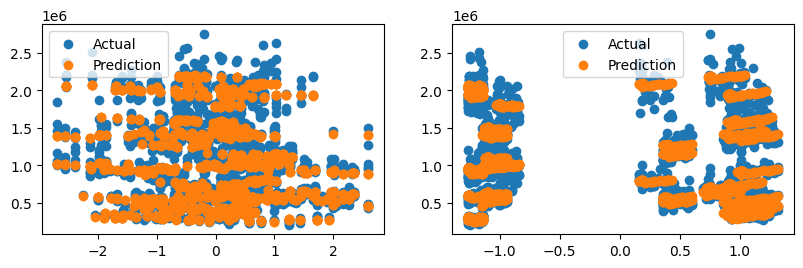



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.9675533912680804
Residual Sum of Squares (RSS) on Training set  ---> 19554227655459.414
Mean Squared Error (MSE) on Training set       ---> 10324301824.424189
Root Mean Squared Error (RMSE) on Training set ---> 101608.57160901431

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.963467087869358
Residual Sum of Squares (RSS) on Training set  ---> 5332868416475.146
Mean Squared Error (MSE) on Training set       ---> 11250777249.947567
Root Mean Squared Error (RMSE) on Training set ---> 106069.68110608973

--------------------Residual Plots--------------------


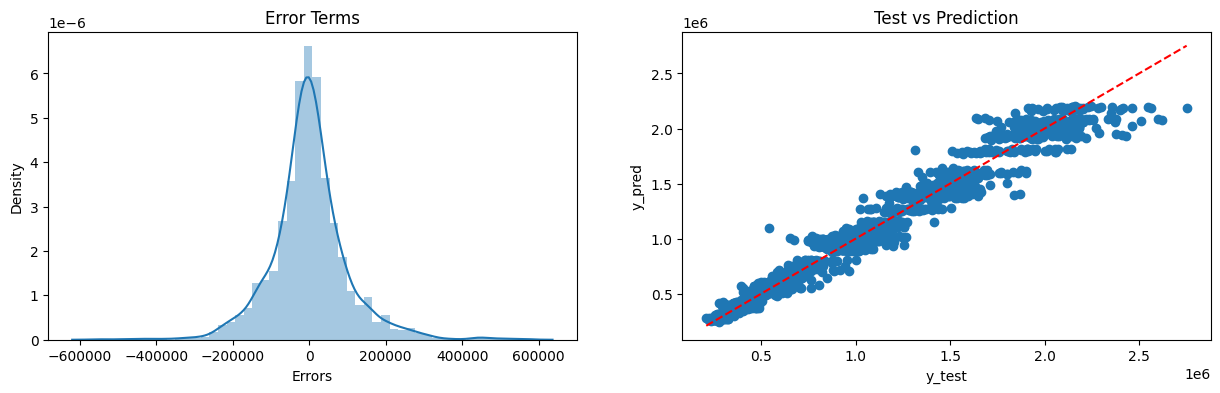

In [34]:
#Creating a Ridge Regression model

RLR = Ridge().fit(Train_X_std,Train_Y)
pred1 = RLR.predict(Train_X_std)
pred2 = RLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Ridge Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
#print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(1, pred1, pred2)

---

## 6c. Lasso Regression Model

<img src="https://raw.githubusercontent.com/Masterx-AI/Master-AI/main/3.%20Machine%20Learning/Z-Etc/Reg/lasso.png" style="width: 500px;float: left;"/>

<<<----------------------------------- Evaluating Lasso Regression Model ----------------------------------->>>

The Intercept of the Regresion Model was found to be  1060946.241494192


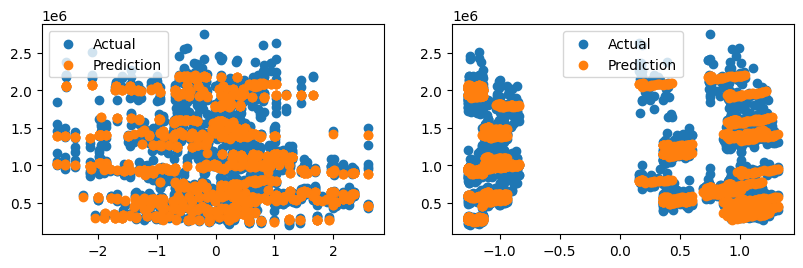



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.967556905078845
Residual Sum of Squares (RSS) on Training set  ---> 19552110027198.293
Mean Squared Error (MSE) on Training set       ---> 10323183752.48062
Root Mean Squared Error (RMSE) on Training set ---> 101603.06960166419

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.9634575159571434
Residual Sum of Squares (RSS) on Training set  ---> 5334265670221.359
Mean Squared Error (MSE) on Training set       ---> 11253725042.661097
Root Mean Squared Error (RMSE) on Training set ---> 106083.5757441325

--------------------Residual Plots--------------------


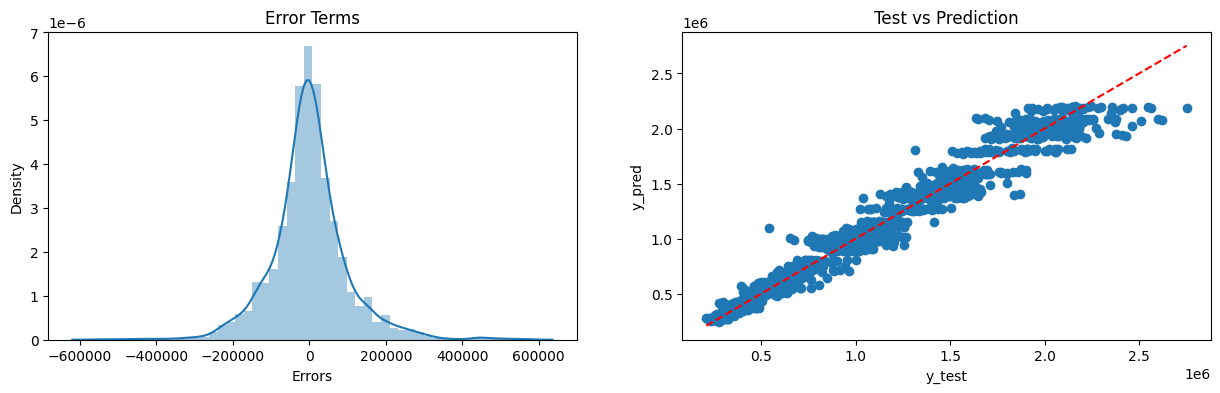

In [35]:
#Creating a Ridge Regression model

LLR = Lasso().fit(Train_X_std,Train_Y)
pred1 = LLR.predict(Train_X_std)
pred2 = LLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Lasso Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
#print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(2, pred1, pred2)

---

## 6d. Elastic-Net Regression

<img src="https://raw.githubusercontent.com/Masterx-AI/Master-AI/main/3.%20Machine%20Learning/Z-Etc/Reg/en.png" style="width: 500px;float: left;"/>

<<<----------------------------------- Evaluating Elastic-Net Regression Model ----------------------------------->>>

The Intercept of the Regresion Model was found to be  1060946.241494192


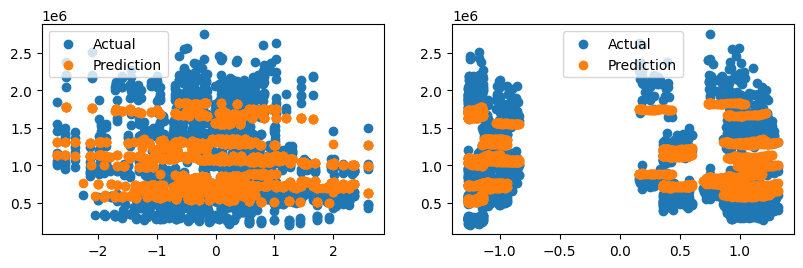



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.8271184057569462
Residual Sum of Squares (RSS) on Training set  ---> 104188578818771.27
Mean Squared Error (MSE) on Training set       ---> 55009809302.41356
Root Mean Squared Error (RMSE) on Training set ---> 234541.70056178403

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.82980789283719
Residual Sum of Squares (RSS) on Training set  ---> 24843683683804.688
Mean Squared Error (MSE) on Training set       ---> 52412834775.95926
Root Mean Squared Error (RMSE) on Training set ---> 228938.49561827572

--------------------Residual Plots--------------------


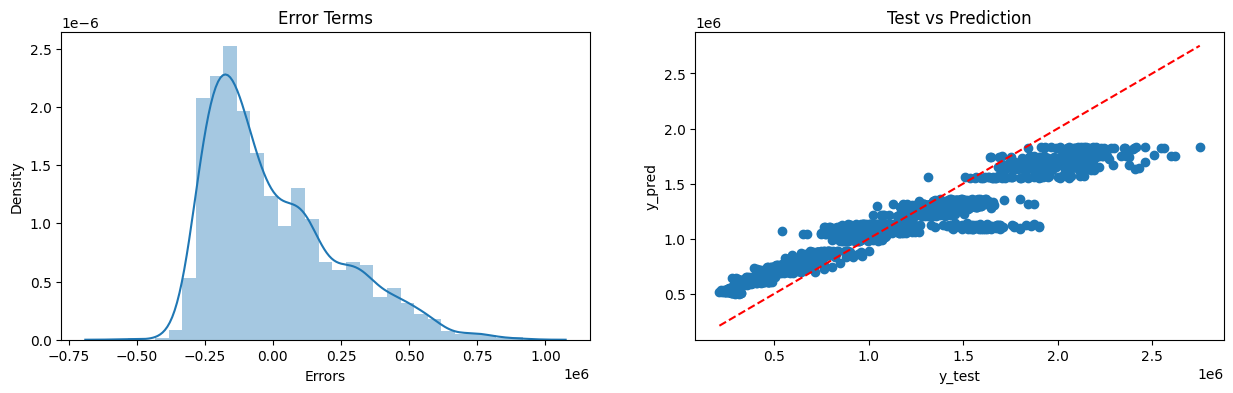

In [36]:
#Creating a ElasticNet Regression model

ENR = ElasticNet().fit(Train_X_std,Train_Y)
pred1 = ENR.predict(Train_X_std)
pred2 = ENR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Elastic-Net Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
#print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(3, pred1, pred2)

---

## 6e. Polynomial Regression Model

<img src="https://raw.githubusercontent.com/Masterx-AI/Master-AI/main/3.%20Machine%20Learning/Z-Etc/Reg/pn.png" style="width: 500px;float: left;"/>

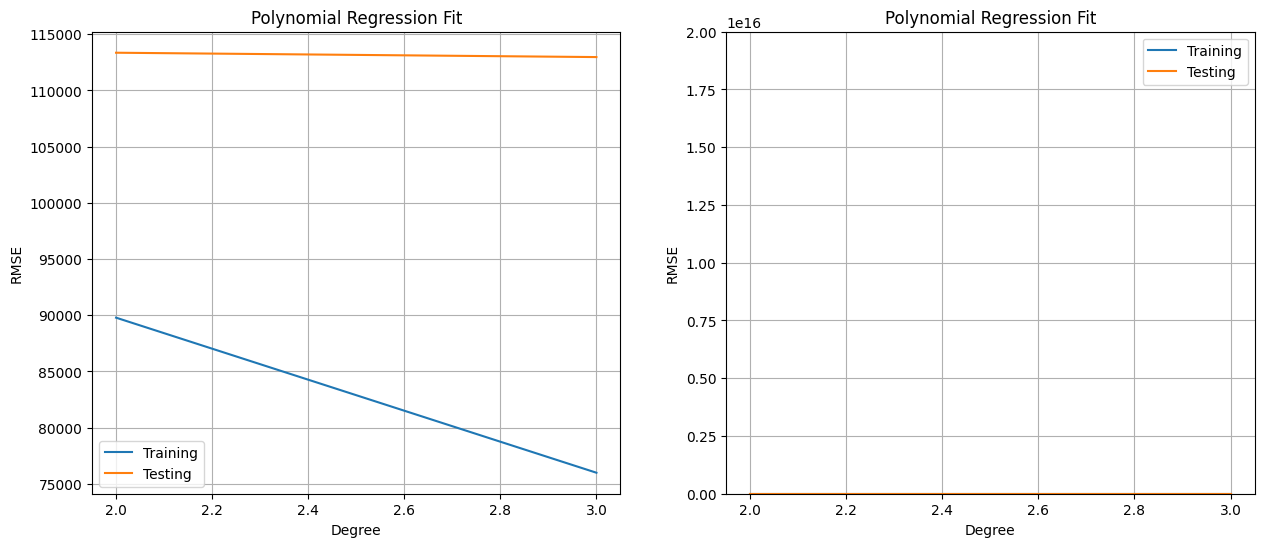

In [37]:
#Checking polynomial regression performance on various degrees

Trr=[]; Tss=[]
n_degree=4

for i in range(2,n_degree):
    #print(f'{i} Degree')
    poly_reg = PolynomialFeatures(degree=i)
    X_poly = poly_reg.fit_transform(Train_X_std)
    X_poly1 = poly_reg.fit_transform(Test_X_std)
    LR = LinearRegression()
    LR.fit(X_poly, Train_Y)

    pred1 = LR.predict(X_poly)
    Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))

    pred2 = LR.predict(X_poly1)
    Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

plt.figure(figsize=[15,6])
plt.subplot(1,2,1)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
#plt.plot([1,4],[1,4],'b--')
plt.title('Polynomial Regression Fit')
#plt.ylim([0,5])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()
#plt.xticks()

plt.subplot(1,2,2)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
plt.title('Polynomial Regression Fit')
plt.ylim([0,2e16])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()
#plt.xticks()
plt.show()

**Inference:** We can choose 2nd order polynomial regression as it gives the optimal training & testing scores...

<<<----------------------------------- Evaluating Polynomial Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 288478.80643786  -13236.46595635  -22709.67162453  -29914.71215941
   56589.08533705 -188456.76371228  154966.77356596 -183516.96677835
 -123613.02064159 -106333.98125479 -166195.77260426  148443.07684615
  -38956.95174184  161769.90277533  108096.22786539  -54619.56447718
 -149407.9033888    18067.8470905    76252.96461522   99048.57617328
 -122205.86906051   49373.21366273   64597.86850828 -133260.71347228
  123918.53059222   20675.67604319  -66007.94527367 -177497.05256052
  -29059.49114941  -42151.06316015 -101575.8123489  -179899.17458069
 -164776.40644536  -24209.3319451   -22572.65007779  -24837.43698598
  -53269.31979846 -138515.81502276  -96132.99901229  -79543.35182063]
The Intercept of the Regresion Model was found to be  1060946.241494192


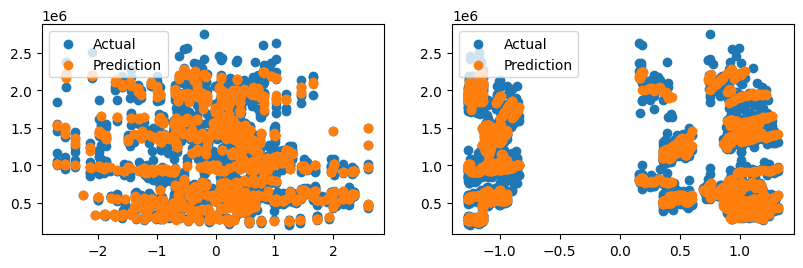



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.974666475656321
Residual Sum of Squares (RSS) on Training set  ---> 15267466206540.414
Mean Squared Error (MSE) on Training set       ---> 8060964206.19874
Root Mean Squared Error (RMSE) on Training set ---> 89782.87256597853

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.9582746828956177
Residual Sum of Squares (RSS) on Training set  ---> 6090826402167.245
Mean Squared Error (MSE) on Training set       ---> 12849844730.310644
Root Mean Squared Error (RMSE) on Training set ---> 113357.15562023706

--------------------Residual Plots--------------------


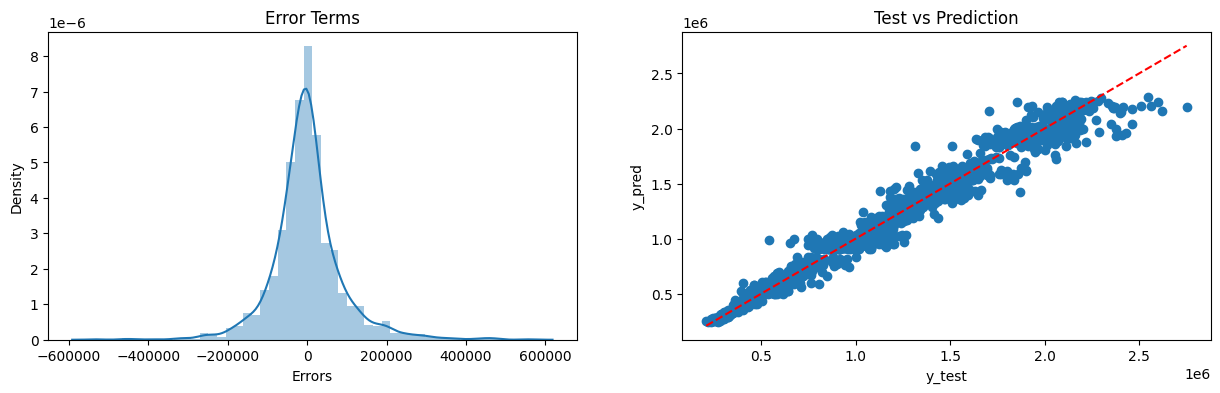

In [38]:
#Using the 2nd Order Polynomial Regression model (degree=2)

poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(Train_X_std)
X_poly1 = poly_reg.fit_transform(Test_X_std)
PR = LinearRegression()
PR.fit(X_poly, Train_Y)

pred1 = PR.predict(X_poly)
pred2 = PR.predict(X_poly1)

print('{}{}\033[1m Evaluating Polynomial Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(4, pred1, pred2)

---

### 6f. Comparing the Evaluation Metics of the Models

In [39]:
# Regression Models Results Evaluation

EMC = Model_Evaluation_Comparison_Matrix.copy()
EMC.index = ['Multiple Linear Regression (MLR)','Ridge Linear Regression (RLR)','Lasso Linear Regression (LLR)','Elastic-Net Regression (ENR)','Polynomial Regression (PNR)']
EMC

,Train-R2,Test-R2,Train-RSS,Test-RSS,Train-MSE,Test-MSE,Train-RMSE,Test-RMSE
Multiple Linear Regression (MLR),0.967557,0.963457,1.955211e+13,5.334323e+12,1.032318e+10,1.125385e+10,101603.068665,106084.143461
Ridge Linear Regression (RLR),0.967553,0.963467,1.955423e+13,5.332868e+12,1.032430e+10,1.125078e+10,101608.571609,106069.681106
Lasso Linear Regression (LLR),0.967557,0.963458,1.955211e+13,5.334266e+12,1.032318e+10,1.125373e+10,101603.069602,106083.575744
Elastic-Net Regression (ENR),0.827118,0.829808,1.041886e+14,2.484368e+13,5.500981e+10,5.241283e+10,234541.700562,228938.495618
Polynomial Regression (PNR),0.974666,0.958275,1.526747e+13,6.090826e+12,8.060964e+09,1.284984e+10,89782.872566,113357.155620


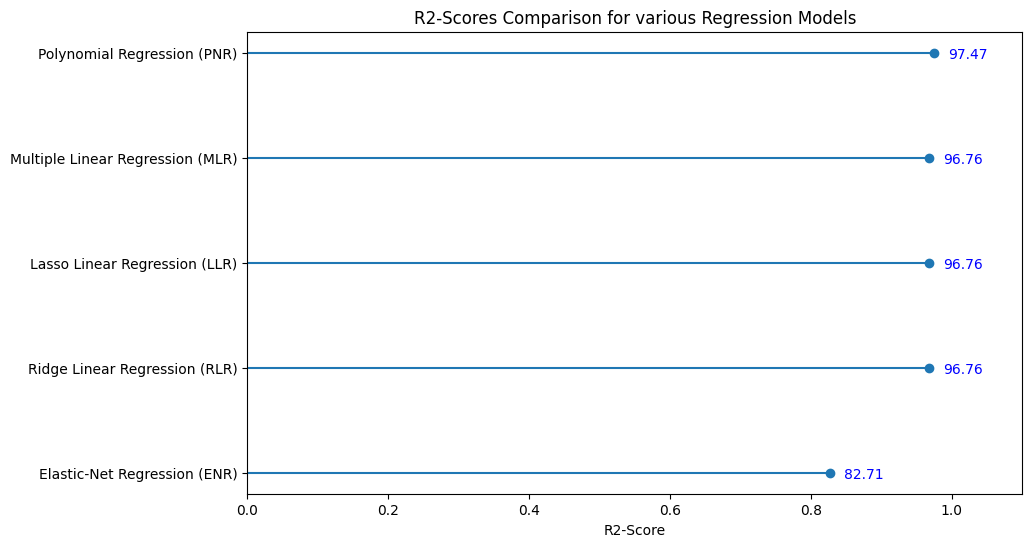

In [40]:
# R2-Scores Comparison for different Regression Models

R2 = round(EMC['Train-R2'].sort_values(ascending=True),4)
plt.hlines(y=R2.index, xmin=0, xmax=R2.values)
plt.plot(R2.values, R2.index,'o')
plt.title('R2-Scores Comparison for various Regression Models')
plt.xlabel('R2-Score')
#plt.ylabel('Regression Models')
for i, v in enumerate(R2):
    plt.text(v+0.02, i-0.05, str(v*100), color='blue')
plt.xlim([0,1.1])
plt.show()

**Inference:** From the above plot, it is clear that the polynomial regresion models have the highest explainability power  to understand the dataset.

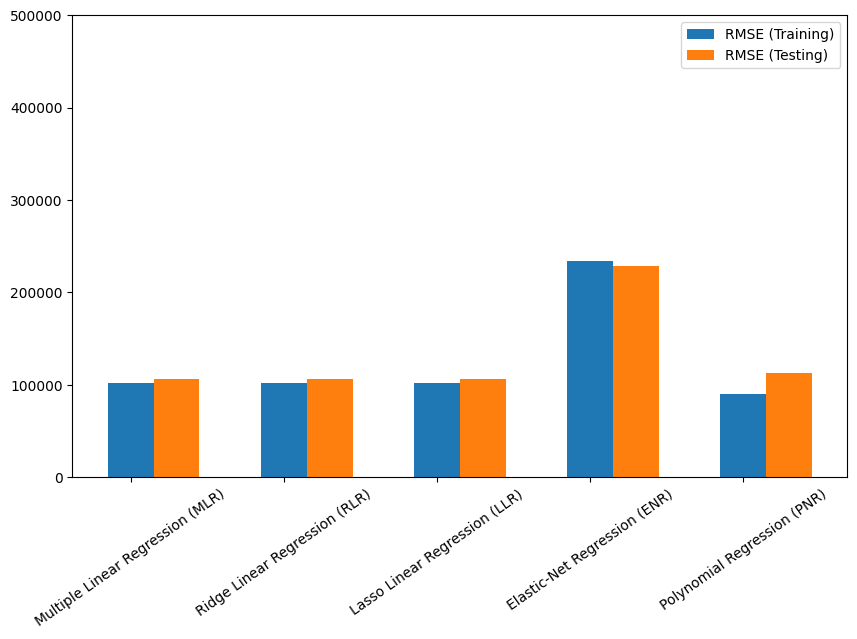

In [41]:
# Root Mean SquaredError Comparison for different Regression Models

cc = Model_Evaluation_Comparison_Matrix.columns.values
s=5

plt.bar(np.arange(5), Model_Evaluation_Comparison_Matrix[cc[6]].values, width=0.3, label='RMSE (Training)')
plt.bar(np.arange(5)+0.3, Model_Evaluation_Comparison_Matrix[cc[7]].values, width=0.3, label='RMSE (Testing)')
plt.xticks(np.arange(5),EMC.index, rotation =35)
plt.legend()
plt.ylim([0,500000])
plt.show()

**Inference:**\
Lesser the RMSE, better the model! Also, provided the model should have close proximity with the training & testing scores. For this problem, it is can be said that polynomial regressions clearly overfitting the current problem. Surprisingly simple Multiple Linear Regression Model gave the best results.

---

# <center> 7. Project Outcomes & Conclusions

### Here are some of the key outcomes of the project:
- The Dataset was quiet small with just 6435 samples & after preprocessing 7.5% of the datasamples were dropped.
- Visualising the distribution of data & their relationships, helped us to get some insights on the feature-set.
- The features had high multicollinearity, hence in Feature Extraction step, we shortlisted the appropriate features with VIF Technique.
- Testing multiple algorithms with default hyperparamters gave us some understanding for various models performance on this specific dataset.
- It is safe to use multiple regression algorithm performed better than other algorithms, as their scores were quiet comparable & also they're more generalisable.